In [12]:
import pandas as pd
df= pd.read_csv("/content/heart.csv")

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [14]:
print(df.shape)

(1025, 14)


In [15]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [16]:
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

In [17]:
dup = df.duplicated().sum()
print(dup)

723


In [18]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


In [19]:
print(df.duplicated().sum())

0


In [20]:
import numpy as np

cols = ["age", "sex", "cp", "trestbps", "chol" , "fbs" , "restecg" ,"thalach" ,"exang" ,"oldpeak" , "slope" , "ca" , "thal"]
df[cols] = df[cols].replace(0, np.nan)

In [21]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [22]:
v_m = df.isnull().sum()
print(v_m)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [23]:
df = df.fillna(df.mean())
print(df)

     age  sex        cp  trestbps  chol  fbs   restecg  thalach  exang  \
0     52  1.0  1.830189       125   212  1.0  1.000000      168    1.0   
1     53  1.0  1.830189       140   203  1.0  1.025806      155    1.0   
2     70  1.0  1.830189       145   174  1.0  1.000000      125    1.0   
3     61  1.0  1.830189       148   203  1.0  1.000000      161    1.0   
4     62  1.0  1.830189       138   294  1.0  1.000000      106    1.0   
..   ...  ...       ...       ...   ...  ...       ...      ...    ...   
723   68  1.0  2.000000       120   211  1.0  1.025806      115    1.0   
733   44  1.0  2.000000       108   141  1.0  1.000000      175    1.0   
739   52  1.0  1.830189       128   255  1.0  1.000000      161    1.0   
843   59  1.0  3.000000       160   273  1.0  1.025806      125    1.0   
878   54  1.0  1.830189       120   188  1.0  1.000000      113    1.0   

      oldpeak     slope        ca  thal  target  
0    1.000000  2.000000  2.000000   3.0       0  
1    3.1000

In [24]:
df["target"].value_counts()

,count
target,
1,164
0,138


In [25]:
for col in df.select_dtypes(include=['float64','int64']).columns: #sélectionne uniquement les colonnes numériques.
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

In [26]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

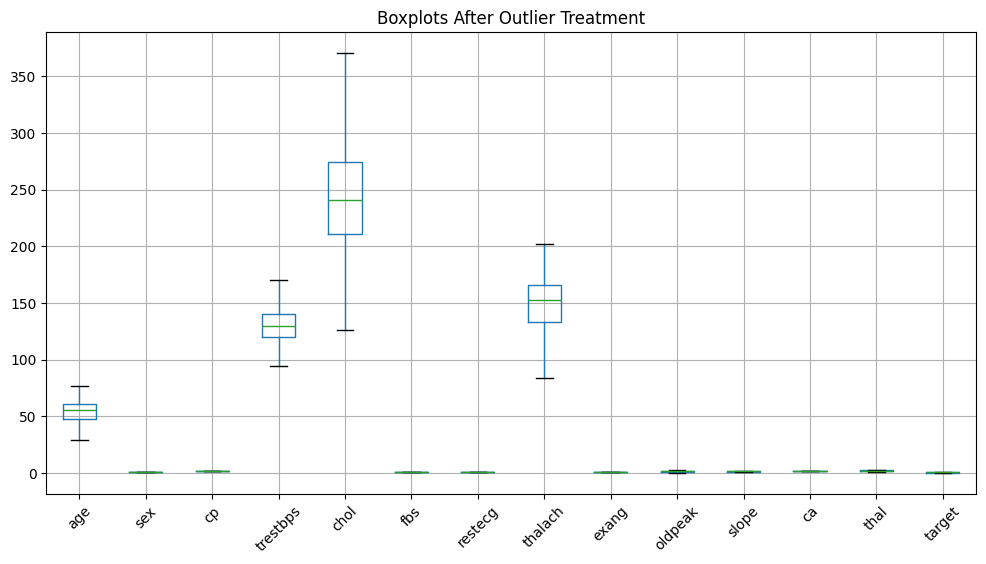

In [44]:
import matplotlib.pyplot  as plt
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Boxplots After Outlier Treatment")
plt.show()

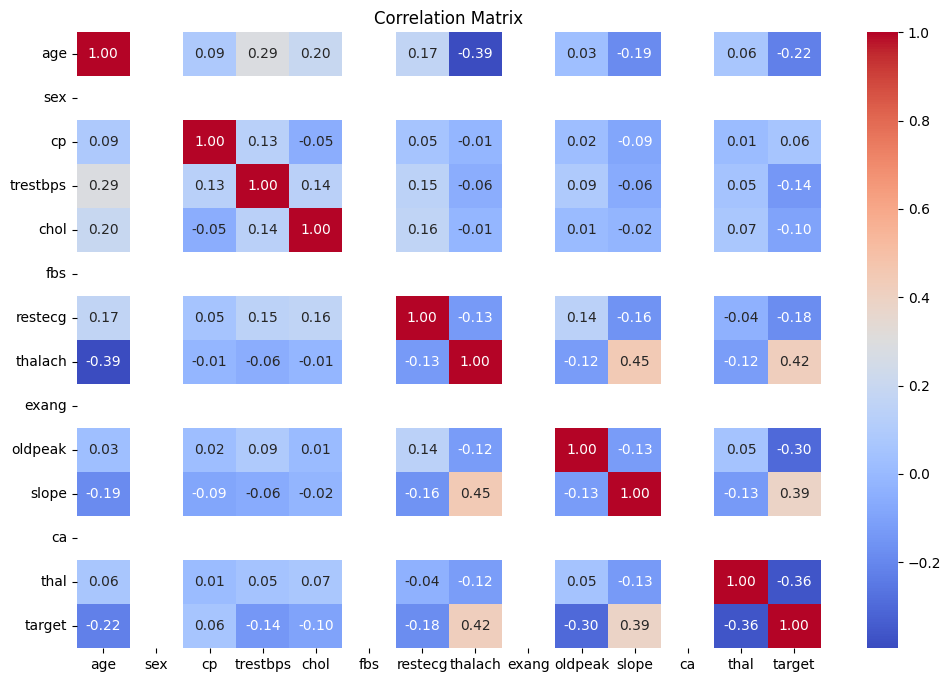

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [46]:
feature_cols = ["age", "sex", "cp", "trestbps", "chol" , "fbs" , "restecg" ,"thalach" ,"exang" ,"oldpeak" , "slope" , "ca" , "thal"]
X = df[feature_cols]
Y= df["target"]

In [47]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X, Y ,  test_size= 0.3 , random_state= 1  )

In [48]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [49]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(211, 13)
(91, 13)
(211,)
(91,)


In [50]:
model.fit( X_train ,Y_train)

y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7912087912087912


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[28  8]
 [11 44]]
              precision    recall  f1-score   support

           0       0.72      0.78      0.75        36
           1       0.85      0.80      0.82        55

    accuracy                           0.79        91
   macro avg       0.78      0.79      0.78        91
weighted avg       0.80      0.79      0.79        91

